In [ ]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np

#load dataset
data = pd.read_excel("../df.xlsx")
df = data.iloc[27:,:] # from 1992-2025


df.set_index('Date', inplace=True)
df = df.sort_values('Date')

# Optional but recommended
#df = df.asfreq('6MS')

ts = df['Production']

# train / test split
train_size = int(len(ts) * 0.8)

train = ts.iloc[:train_size]
test = ts.iloc[train_size:]

In [ ]:
# Multiplicative
model_mul = ExponentialSmoothing(
    train,
    trend='mul',
    seasonal='mul',
    seasonal_periods=2
).fit()





C:\Users\User\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
model_mul.summary()

Dep. Variable:,Production,No. Observations:,53
Model:,ExponentialSmoothing,SSE,4439519.633
Optimized:,True,AIC,612.796
Trend:,Multiplicative,BIC,624.617
Seasonal:,Multiplicative,AICC,616.068
Seasonal Periods:,2,Date:,"Mon, 18 May 2026"
Box-Cox:,False,Time:,12:13:10
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,1.4901e-08,alpha,True
smoothing_trend,0.000000,beta,True


In [ ]:
forecast_mul = model_mul.forecast(len(test))
forecast_mul

C:\Users\User\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\User\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


53    2686.460580
54    1622.921934
55    2745.169618
56    1658.388743
57    2805.161665
58    1694.630633
59    2866.464758
60    1731.664541
61    2929.107549
62    1769.507776
63    2993.119315
64    1808.178025
65    3058.529973
66    1847.693361
dtype: float64

In [ ]:
rmse_mul = np.sqrt(mean_squared_error(test, forecast_mul))
mape_mul = mean_absolute_percentage_error(test, forecast_mul) * 100

In [ ]:
print("\nMultiplicative Model")
print("RMSE:", rmse_mul)
print("MAPE:", mape_mul)


Multiplicative Model
RMSE: 384.6422217759986
MAPE: 14.4680806488348


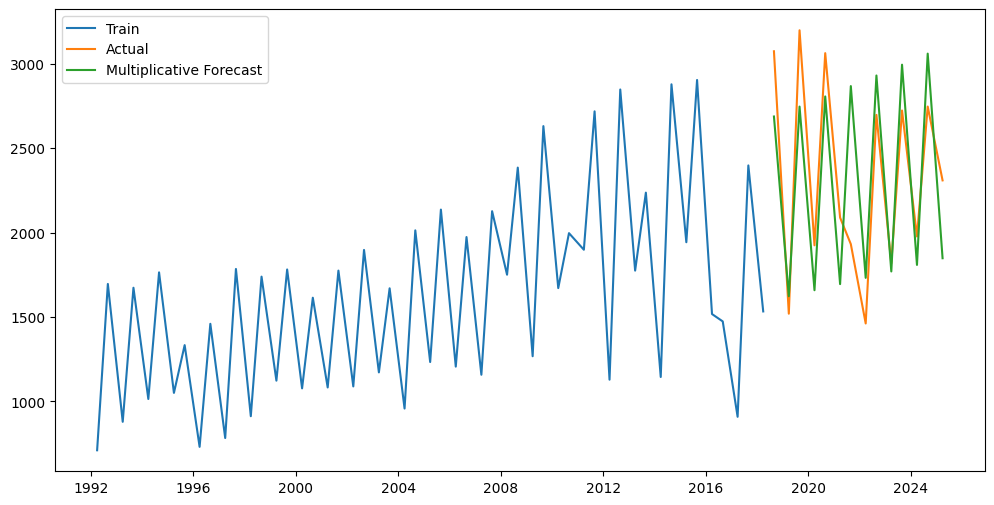

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(
    test.index,
    forecast_mul,
    label='Multiplicative Forecast'
)
plt.legend()
